In [107]:
from pathlib import Path
from typing import Optional, Tuple
import tifffile
from liffile import LifFile
import numpy as np
import napari
import os
from magicgui import magicgui
from magicgui.widgets import Container, TextEdit
from skimage import util
from skimage.filters import threshold_triangle, median, sobel, gaussian, threshold_yen, threshold_otsu
from skimage.measure import label, regionprops_table, regionprops, moments_central
from skimage.morphology import disk, remove_small_objects, remove_small_holes, closing, opening, binary_opening, binary_closing, erosion
from skimage.transform import ProjectiveTransform, warp, probabilistic_hough_line
from scipy.ndimage import rotate, binary_dilation, binary_fill_holes
from skimage.draw import line
from skimage.io import imread
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


In [39]:
image_folder = Path(r"Z:\\Bel\\Marina_Area_PDO\\260310")
png_paths = sorted(image_folder.glob("*.png"))

In [118]:
test = gaussian(util.invert(imread(png_paths[4])),sigma=1)

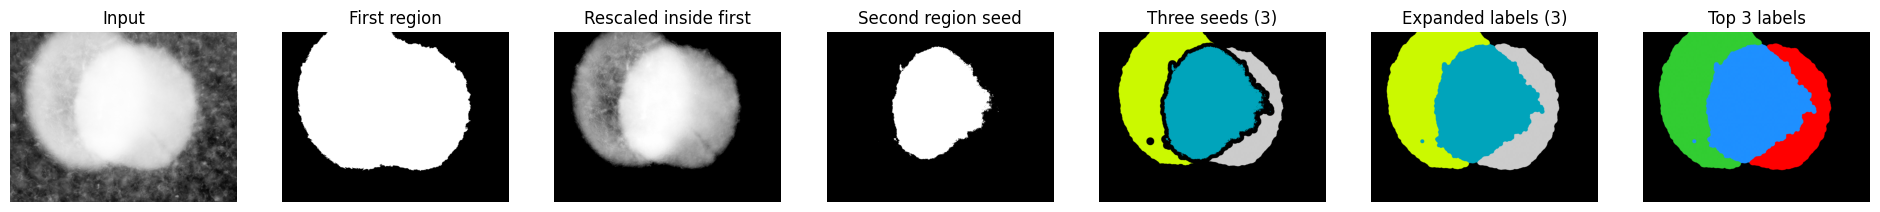

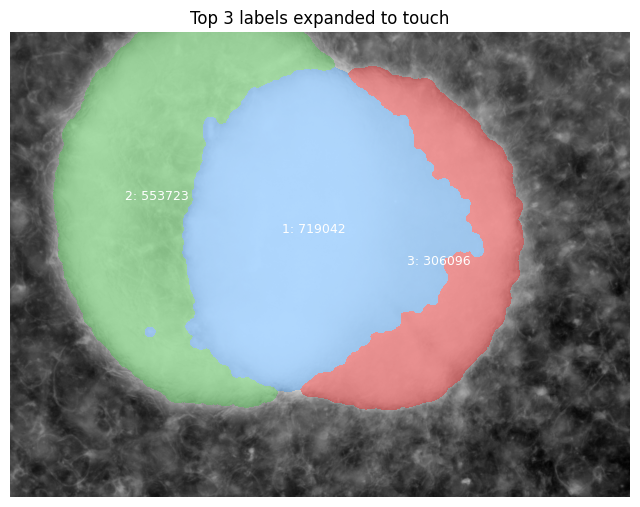

First region area: 1593466 px
Label 1 (second_region) area: 719042 px
Label 2 (first_region_part_1) area: 553723 px
Label 3 (first_region_part_2) area: 306096 px


In [135]:

from skimage import exposure
from skimage.filters import threshold_multiotsu
from skimage.segmentation import expand_labels

thresh_yen = threshold_otsu(test)
binary_yen = test > thresh_yen
binary_yen = remove_small_holes(binary_yen, max_size=16000)

binary_yen_labels = label(binary_yen)
if binary_yen_labels.max() > 0:
    first_regions = sorted(regionprops(binary_yen_labels), key=lambda region: region.area, reverse=True)
    first_region = binary_yen_labels == first_regions[0].label
else:
    first_regions = []
    first_region = np.zeros_like(binary_yen, dtype=bool)

masked_rescaled = np.zeros_like(test, dtype=float)
if first_region.any():
    low, high = np.percentile(test[first_region], (2, 99))
    masked_rescaled[first_region] = exposure.rescale_intensity(
        test[first_region],
        in_range=(low, high),
        out_range=(0, 1),
    )

first_region_classes = np.zeros_like(binary_yen, dtype=int)
second_region = np.zeros_like(binary_yen, dtype=bool)
if first_region.any() and np.unique(masked_rescaled[first_region]).size > 1:
    thresholds = threshold_multiotsu(masked_rescaled[first_region], classes=3)
    first_region_classes[first_region] = np.digitize(masked_rescaled[first_region], bins=thresholds)
    second_region = first_region & (first_region_classes == first_region_classes[first_region].max())

remainder_region = first_region & ~second_region
remainder_region = remove_small_objects(remainder_region, max_size=499)

split_erosion_radius = 35
split_expand_distance = 35
eroded_remainder = erosion(remainder_region, disk(split_erosion_radius))
raw_seed_labels = label(eroded_remainder)
raw_seed_regions = sorted(regionprops(raw_seed_labels), key=lambda region: region.area, reverse=True)

seed_labels = np.zeros_like(raw_seed_labels, dtype=int)
if second_region.any():
    seed_labels[second_region] = 1

for new_label, region in enumerate(raw_seed_regions[:2], start=2):
    seed_labels[raw_seed_labels == region.label] = new_label

expanded_all_labels = expand_labels(seed_labels, distance=split_expand_distance)
expanded_all_labels = expanded_all_labels * first_region.astype(int)
final_regions = sorted(regionprops(expanded_all_labels), key=lambda region: region.area, reverse=True)

combined_labels = np.zeros_like(binary_yen, dtype=int)
for new_label, region in enumerate(final_regions[:3], start=1):
    combined_labels[expanded_all_labels == region.label] = new_label

region_summaries = []
for label_value in range(1, combined_labels.max() + 1):
    region_mask = combined_labels == label_value
    if not region_mask.any():
        continue
    region_coords = np.argwhere(region_mask)
    region_centroid = tuple(region_coords.mean(axis=0))
    if label_value == 1:
        region_name = "second_region"
    else:
        region_name = f"first_region_part_{label_value - 1}"
    region_summaries.append((label_value, region_name, int(region_mask.sum()), region_centroid))

combined_cmap = ListedColormap(["black", "darkorange", "dodgerblue", "deeppink", "limegreen", "red"])

fig, ax = plt.subplots(ncols=7, figsize=(24, 4))
ax[0].imshow(test, cmap="gray")
ax[0].set_title("Input")
ax[1].imshow(first_region, cmap="gray")
ax[1].set_title("First region")
ax[2].imshow(masked_rescaled, cmap="gray")
ax[2].set_title("Rescaled inside first")
ax[3].imshow(second_region, cmap="gray")
ax[3].set_title("Second region seed")
ax[4].imshow(seed_labels, cmap="nipy_spectral")
ax[4].set_title(f"Three seeds ({int(seed_labels.max())})")
ax[5].imshow(expanded_all_labels, cmap="nipy_spectral")
ax[5].set_title(f"Expanded labels ({len(final_regions[:3])})")
ax[6].imshow(combined_labels, cmap=combined_cmap, vmin=0, vmax=max(1, combined_labels.max()))
ax[6].set_title("Top 3 labels")

for axis in ax:
    axis.axis("off")

plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(test, cmap="gray")
ax.imshow(
    combined_labels,
    cmap=combined_cmap,
    vmin=0,
    vmax=max(1, combined_labels.max()),
    alpha=np.where(combined_labels > 0, 0.35, 0.0),
    interpolation="none",
)

for label_value, region_name, area, centroid in region_summaries:
    y_coord, x_coord = centroid
    ax.text(
        x_coord,
        y_coord,
        f"{label_value}: {area}",
        color="white",
        ha="center",
        va="center",
        fontsize=9,
    )

ax.set_title("Top 3 labels expanded to touch")
ax.axis("off")
plt.show()

print(f"First region area: {int(first_region.sum())} px")
for label_value, region_name, area, centroid in region_summaries:
    print(f"Label {label_value} ({region_name}) area: {area} px")